In [1]:
! pip install ucimlrepo

## **Data cleaning**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Access Adult Dataset
adult = fetch_ucirepo(id=2)

# Access (X) and target（y）
X = adult.data.features
y = adult.data.targets

# Combine X and y
X["income"] = y


In [ ]:
# 把 X 寫成 excel



In [3]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
import missingno

print("Missingno Version : {}".format(missingno.__version__))

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

Missingno Version : 0.5.2


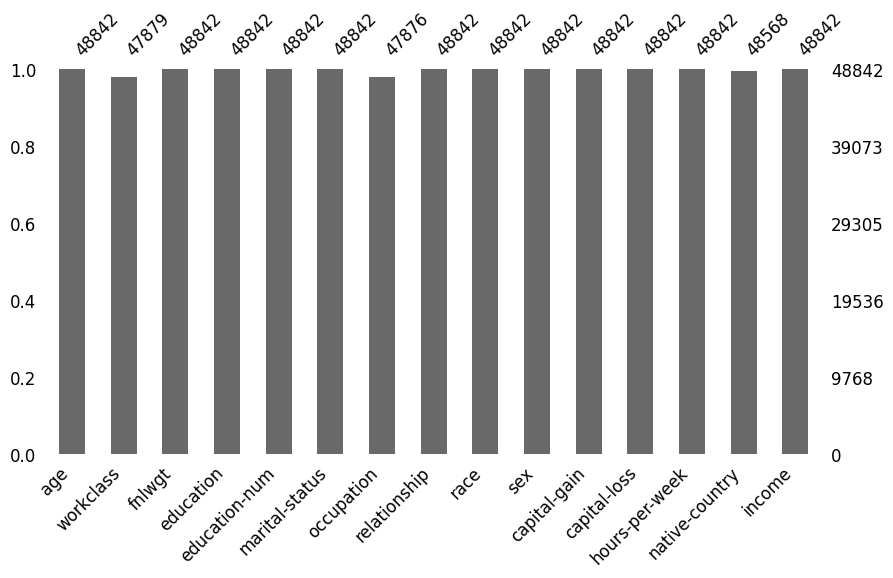

In [5]:
missingno.bar(X, figsize=(10,5), fontsize=12);

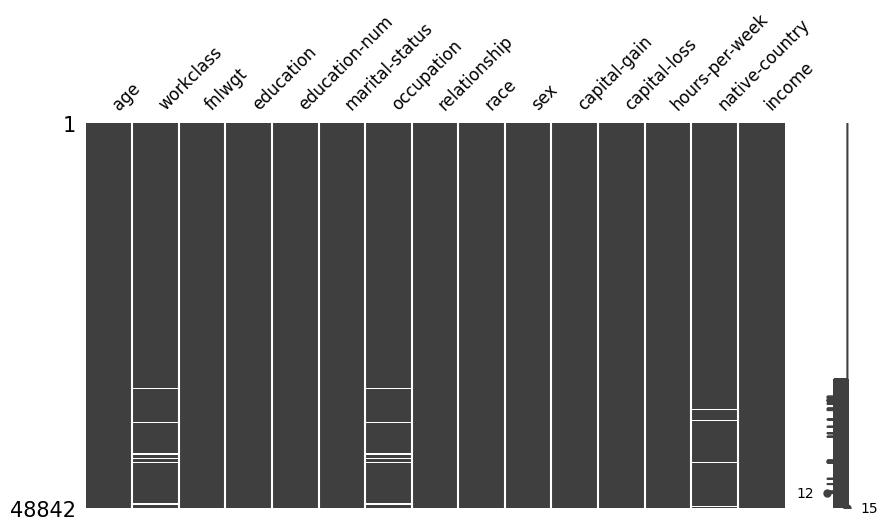

In [6]:
missingno.matrix(X,figsize=(10,5), fontsize=12);

In [ ]:
# Remove misssing values
X_clean = X.dropna().copy()
X_clean.replace("?", np.nan, inplace=True)
X_clean.dropna(inplace=True)

# Check Data row numbers
print("Before data cleaning:", X.shape)
print("After data cleaning:", X_clean.shape)

# Check whether the missing values exist

print("X_clean missing values statistics and data types\n")
print("{:<13} {:<10} {:<10}".format("column name", "missing values", "data types"))
print("-" * 45)
for col in X_clean.columns:
    print("{:<20} {:<10} {:<10}".format(col, X_clean[col].isnull().sum(), str(X_clean[col].dtype)))

Before data cleaning: (48842, 15)
After data cleaning: (45222, 15)
X_clean missing values statistics and data types

column name   missing values data types
---------------------------------------------
age                  0          int64     
workclass            0          object    
fnlwgt               0          int64     
education            0          object    
education-num        0          int64     
marital-status       0          object    
occupation           0          object    
relationship         0          object    
race                 0          object    
sex                  0          object    
capital-gain         0          int64     
capital-loss         0          int64     
hours-per-week       0          int64     
native-country       0          object    
income               0          object    


In [ ]:
# clean target y: ',' or ' '
X_clean["income"] = X_clean["income"].str.replace(".", "", regex=False)
X_clean["income"] = X_clean["income"].str.strip()


In [ ]:
# Before: target
print(X["income"].unique())
# After: target
print(X_clean["income"].unique())

['<=50K' '>50K' '<=50K.' '>50K.']
['<=50K' '>50K']


In [ ]:
# categorical columns
categorical_columns = ["workclass", "education", "marital-status", "occupation",
                       "relationship", "race", "sex", "native-country", "income"]

print("categorical columns")
for col in categorical_columns:
    print(f"{col} unique values: \n{X_clean[col].unique()}")

# numerical columns
numerical_columns = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

print("\n numerical columns")
print(X_clean[numerical_columns].describe())


categorical columns
workclass unique values: 
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay']
education unique values: 
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 '7th-8th' 'Doctorate' 'Assoc-voc' 'Prof-school' '5th-6th' '10th'
 'Preschool' '12th' '1st-4th']
marital-status unique values: 
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation unique values: 
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Transport-moving' 'Farming-fishing'
 'Machine-op-inspct' 'Tech-support' 'Craft-repair' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
relationship unique values: 
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race unique values: 
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex unique values: 
['Male' 'Female']
native-country

In [ ]:
! pip install pandas openpyxl


In [ ]:
import pandas as pd

df = X_clean

# 先寫到 Colab 本地
df.to_excel('/content/output.xlsx', index=False)




## **Data Visualization code here:**

<ipython-input-29-56cc6077e617>:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



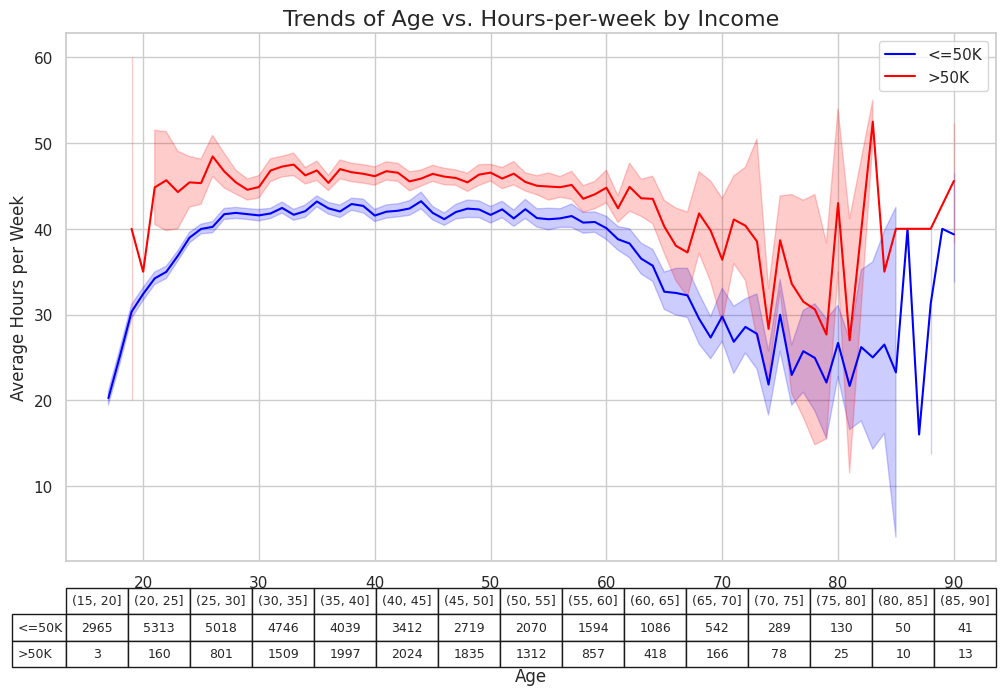

In [ ]:
# (1) Age vs. Hours-Per-Week vs. Income +table
bins = range(15, 95, 5)
X_clean["age_group"] = pd.cut(X_clean["age"], bins)
# Count samples in each age group and income level
age_group_counts = X_clean.groupby(["age_group", "income"]).size().unstack()
# new_order = ['>50K', '<=50K']
# age_group_counts = age_group_counts[new_order]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Age vs. Hours-per-week
sns.lineplot(x='age', y='hours-per-week', data=X_clean, hue='income', estimator='mean',
             palette={'<=50K': 'blue', '>50K': 'red'}, ax=ax)

# Titles and labels
ax.set_title('Trends of Age vs. Hours-per-week by Income', fontsize=16)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Average Hours per Week', fontsize=12)
ax.legend(loc='upper right')

# Convert age_group to string format for table display
age_group_counts.index = age_group_counts.index.astype(str)

# Create Table right below X-axis labels
table = plt.table(cellText=age_group_counts.T.values,
                  colLabels=age_group_counts.index,
                  rowLabels=['<=50K', '>50K'],
                  cellLoc='center',
                  loc='bottom',
                  bbox=[0, -0.2, 1, 0.15])

ax.xaxis.set_label_coords(0.5, -0.2)

plt.subplots_adjust(bottom=0)

plt.show()

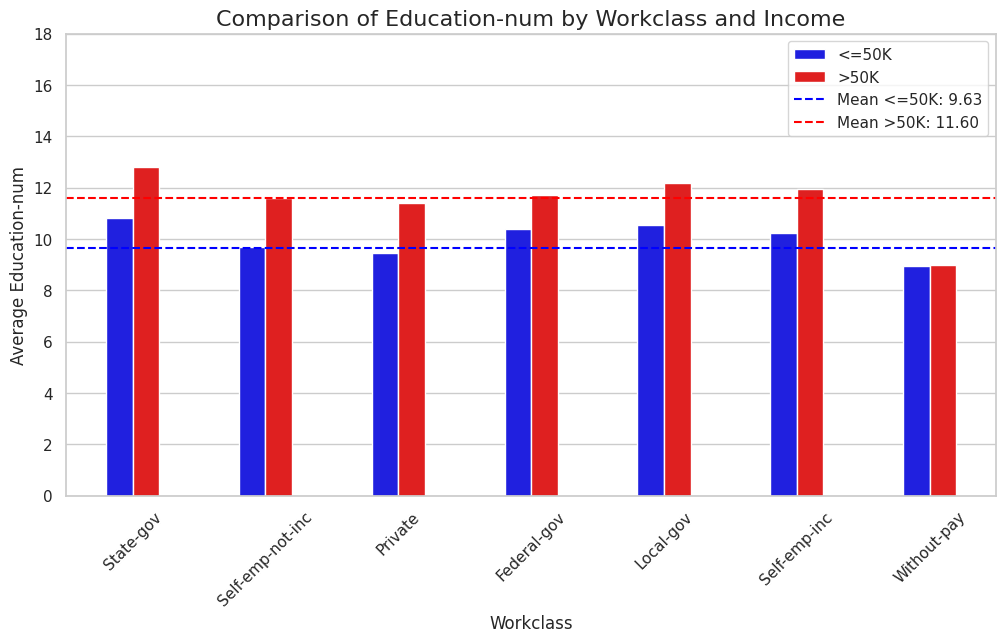

In [ ]:

# (2) Workclass vs. Income vs. Education-Num

# Calculate average education-num for each income group
mean_lte_50k = X_clean[X_clean['income'] == '<=50K']['education-num'].mean()
mean_gt_50k = X_clean[X_clean['income'] == '>50K']['education-num'].mean()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='workclass', y='education-num', hue='income', data=X_clean, palette={'<=50K': 'blue', '>50K': 'red'}, width=0.4, errorbar=None)
plt.title('Comparison of Education-num by Workclass and Income', fontsize=16)
plt.xlabel('Workclass', fontsize=12)
plt.ylabel('Average Education-num', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 18)
plt.legend(loc='upper right')

# Add horizontal lines for average education-num
plt.axhline(mean_lte_50k, color='blue', linestyle='--', label=f'Mean <=50K: {mean_lte_50k:.2f}')
plt.axhline(mean_gt_50k, color='red', linestyle='--', label=f'Mean >50K: {mean_gt_50k:.2f}')

# Update legend to include mean lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right")

plt.show()

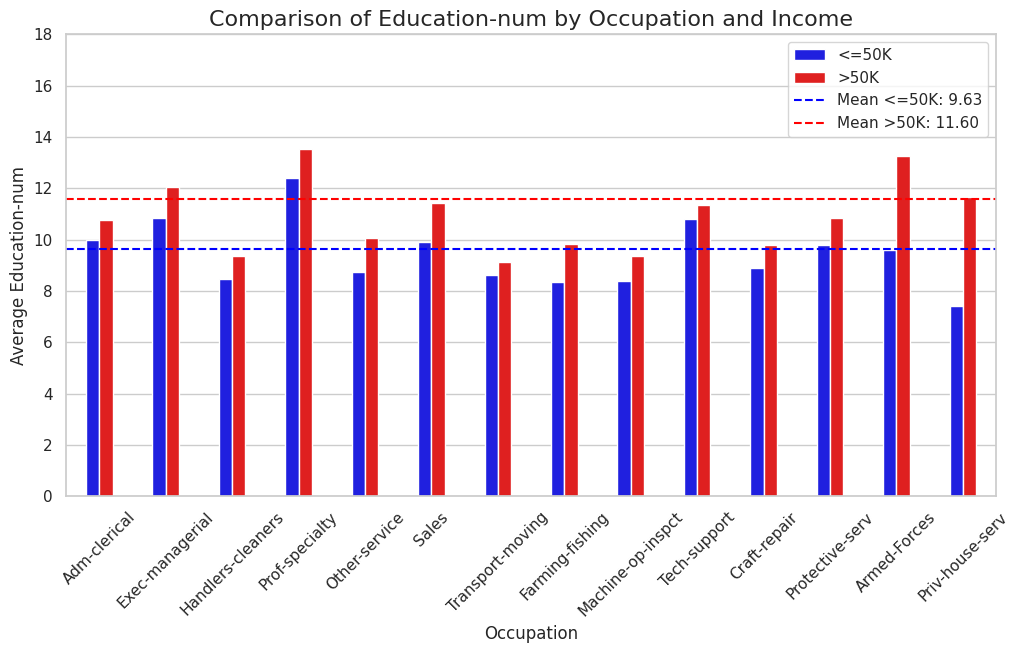

In [ ]:

# (2) Workclass vs. Income vs. Education-Num

# Calculate average education-num for each income group
mean_lte_50k = X_clean[X_clean['income'] == '<=50K']['education-num'].mean()
mean_gt_50k = X_clean[X_clean['income'] == '>50K']['education-num'].mean()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='occupation', y='education-num', hue='income', data=X_clean, palette={'<=50K': 'blue', '>50K': 'red'}, width=0.4, errorbar=None)
plt.title('Comparison of Education-num by Occupation and Income', fontsize=16)
plt.xlabel('Occupation', fontsize=12)
plt.ylabel('Average Education-num', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 18)
plt.legend(loc='upper right')

# Add horizontal lines for average education-num
plt.axhline(mean_lte_50k, color='blue', linestyle='--', label=f'Mean <=50K: {mean_lte_50k:.2f}')
plt.axhline(mean_gt_50k, color='red', linestyle='--', label=f'Mean >50K: {mean_gt_50k:.2f}')

# Update legend to include mean lines
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="upper right")
